In [1]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print(os.getcwd())

c:\Users\STUDENT\Downloads\land_monitor\land-monitor


In [2]:
from ml.data import compute_channel_stats, load_eurosat, save_stats, build_dataloaders
import matplotlib.pyplot as plt
import numpy as np
from ml.splits import make_splits, save_splits
from collections import Counter
import torch
import json
from pathlib import Path
from ml.transform import eval_transforms, train_transforms
from sklearn.metrics import classification_report,ConfusionMatrixDisplay
from ml.evaluate import predict
from ml.model import build_model

In [3]:
ds=load_eurosat("data/EuroSAT")
print(len(ds), ds.classes)

27000 ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


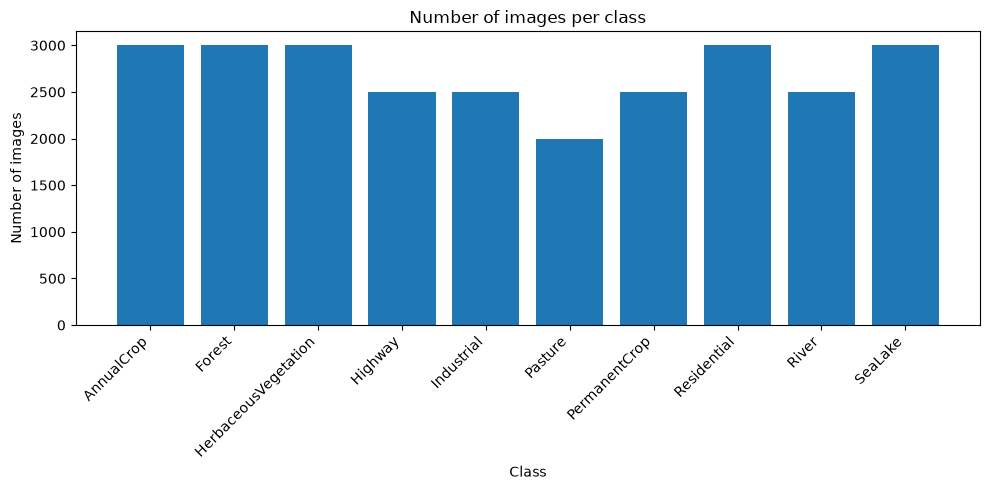

In [4]:
class_counts = [
    len([1 for _, label in ds if label == i])
    for i in range(len(ds.classes))
]
plt.figure(figsize=(10, 5))
plt.bar(ds.classes, class_counts)

plt.xlabel("Class")
plt.ylabel("Number of images")
plt.title("Number of images per class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

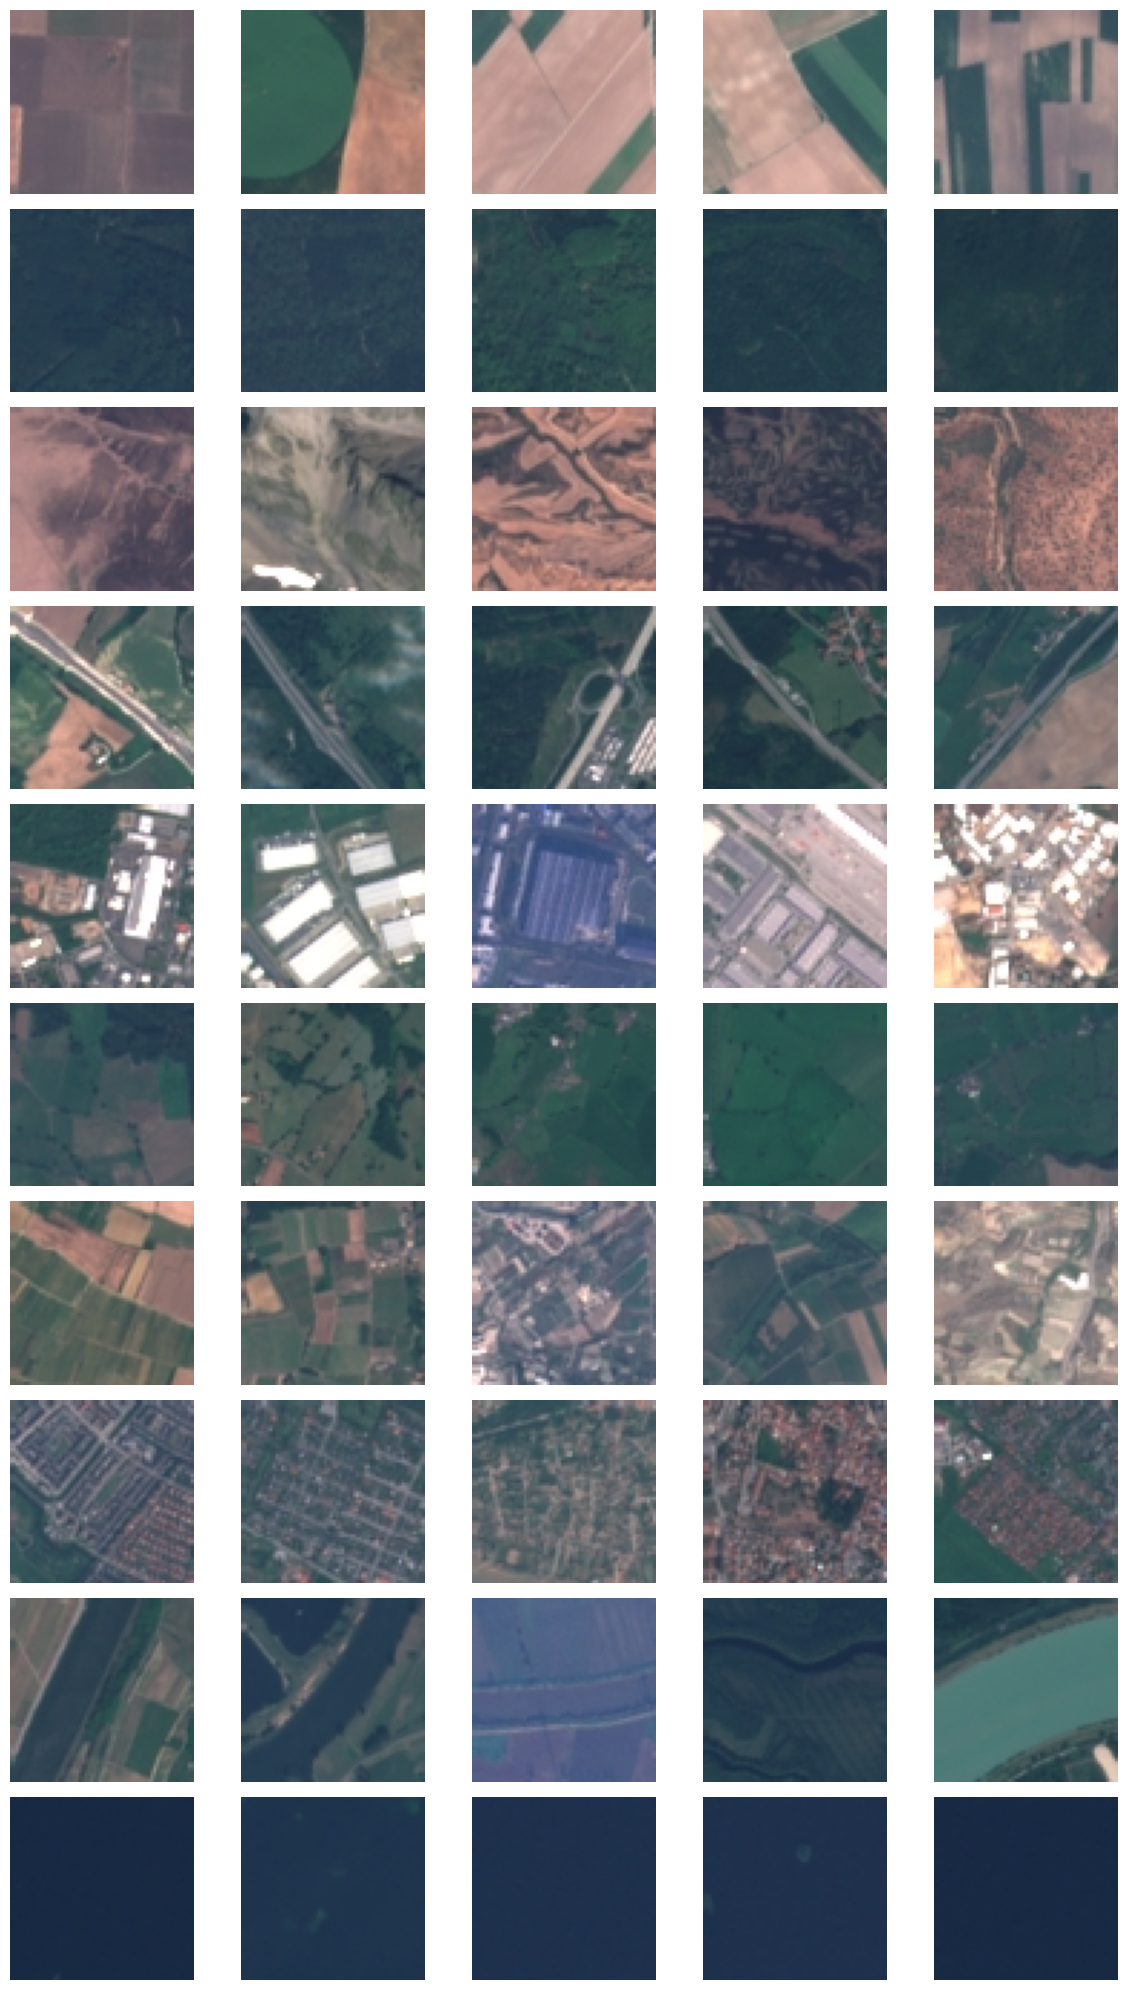

In [5]:
n_classes = len(ds.classes)
images_per_class = 5

fig, axes = plt.subplots(
    n_classes,
    images_per_class,
    figsize=(12, 20)
)

for class_id in range(n_classes):
    count = 0

    for image, label in ds:
        if label == class_id:
            axes[class_id, count].imshow(image)
            axes[class_id, count].axis("off")

            if count == 0:
                axes[class_id, count].set_ylabel(
                    ds.classes[class_id],
                    fontsize=10
                )

            count += 1

            if count == images_per_class:
                break

plt.tight_layout()
plt.show()

In [6]:
for i in range(5):
    image, label = ds[i]

    image_array = np.array(image)

    print(f"Image {i}")
    print(f"  Class: {ds.classes[label]}")
    print(f"  Size: {image.size}")
    print(f"  Mode: {image.mode}")
    print(f"  Pixel range: {image_array.min()} - {image_array.max()}")
    print()

Image 0
  Class: AnnualCrop
  Size: (64, 64)
  Mode: RGB
  Pixel range: 82 - 204

Image 1
  Class: AnnualCrop
  Size: (64, 64)
  Mode: RGB
  Pixel range: 35 - 216

Image 2
  Class: AnnualCrop
  Size: (64, 64)
  Mode: RGB
  Pixel range: 61 - 221

Image 3
  Class: AnnualCrop
  Size: (64, 64)
  Mode: RGB
  Pixel range: 50 - 245

Image 4
  Class: AnnualCrop
  Size: (64, 64)
  Mode: RGB
  Pixel range: 50 - 187



In [7]:
pixels = []

for image, _ in ds:
    image_array = np.array(image).astype(np.float32) / 255.0
    pixels.append(image_array)

pixels = np.stack(pixels)

mean = pixels.mean(axis=(0, 1, 2))
std = pixels.std(axis=(0, 1, 2))

print("EuroSAT mean:", mean)
print("EuroSAT std:", std)

print("ImageNet mean:", [0.485, 0.456, 0.406])
print("ImageNet std:", [0.229, 0.224, 0.225])

EuroSAT mean: [0.1517037 0.1517037 0.1517037]
EuroSAT std: [0.23919559 0.20684686 0.20701489]
ImageNet mean: [0.485, 0.456, 0.406]
ImageNet std: [0.229, 0.224, 0.225]


In [8]:
splits = make_splits(ds.targets, seed=42)
save_splits(splits, "configs/eurosat_splits.json")
print({name: len(idx) for name, idx in splits.items()})

train, val, test = (set(splits[k]) for k in ("train", "val", "test"))
assert not (train & val) and not (train & test) and not (val & test), "Splits overlap!"
assert len(train | val | test) == len(ds), "Some images are missing!"

stats = compute_channel_stats(ds, splits["train"])
save_stats(stats, "configs/eurosat_stats.json")
stats

{'train': 18899, 'val': 4051, 'test': 4050}


{'mean': [0.3448285981648428, 0.38055294078889723, 0.40827726149033144],
 'std': [0.20308357962054155, 0.13713164683432152, 0.11561780855227277]}

In [9]:
loaders = build_dataloaders(
    "data", "configs/eurosat_splits.json", "configs/eurosat_stats.json"
)
images, labels = next(iter(loaders["train"]))

print("images:", images.shape, images.dtype)
print("labels:", labels.shape)
print("batch mean per channel:", images.mean(dim=(0, 2, 3)))
print("batch std per channel: ", images.std(dim=(0, 2, 3)))

images: torch.Size([64, 3, 64, 64]) torch.float32
labels: torch.Size([64])
batch mean per channel: tensor([-0.0572, -0.0384, -0.0382])
batch std per channel:  tensor([0.9720, 0.9751, 0.9595])


In [10]:
for name in ("train", "val", "test"):
    counts = Counter(ds.targets[i] for i in splits[name])
    total = len(splits[name])
    shares = {ds.classes[c]: round(n / total, 3) for c, n in sorted(counts.items())}
    print(name, shares)

train {'AnnualCrop': 0.111, 'Forest': 0.111, 'HerbaceousVegetation': 0.111, 'Highway': 0.093, 'Industrial': 0.093, 'Pasture': 0.074, 'PermanentCrop': 0.093, 'Residential': 0.111, 'River': 0.093, 'SeaLake': 0.111}
val {'AnnualCrop': 0.111, 'Forest': 0.111, 'HerbaceousVegetation': 0.111, 'Highway': 0.093, 'Industrial': 0.093, 'Pasture': 0.074, 'PermanentCrop': 0.093, 'Residential': 0.111, 'River': 0.093, 'SeaLake': 0.111}
test {'AnnualCrop': 0.111, 'Forest': 0.111, 'HerbaceousVegetation': 0.111, 'Highway': 0.093, 'Industrial': 0.093, 'Pasture': 0.074, 'PermanentCrop': 0.093, 'Residential': 0.111, 'River': 0.093, 'SeaLake': 0.111}


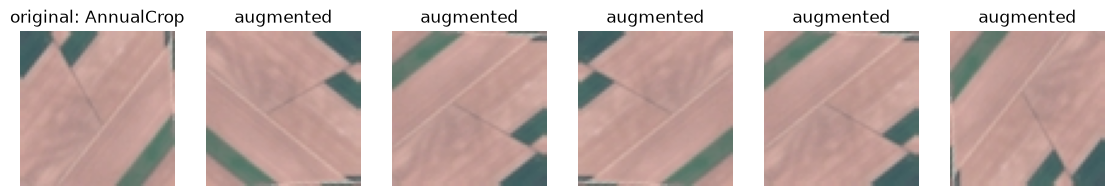

In [11]:
mean, std = stats["mean"], stats["std"]


def to_display(x: torch.Tensor) -> torch.Tensor:
    """Undo normalization so the image looks normal on screen."""
    x = x * torch.tensor(std).view(3, 1, 1) + torch.tensor(mean).view(3, 1, 1)
    return x.clamp(0, 1).permute(1, 2, 0)


image, label = ds[splits["train"][0]]
augment = train_transforms(mean, std)

fig, axes = plt.subplots(1, 6, figsize=(14, 3))
axes[0].imshow(to_display(eval_transforms(mean, std)(image)))
axes[0].set_title(f"original: {ds.classes[label]}")
for ax in axes[1:]:
    ax.imshow(to_display(augment(image)))
    ax.set_title("augmented")
for ax in axes:
    ax.axis("off")
plt.show()

In [12]:
history_path=Path("models/history.json")
history = json.loads(history_path.read_text()) if history_path.exists() else {}

In [13]:
class_names = ds.classes

In [14]:
model = build_model(num_classes=10, pretrained=False)
state_dict=torch.load("models/best_model.pth", map_location=torch.device("cpu"), weights_only=True)
model.load_state_dict(state_dict)

<All keys matched successfully>

In [16]:

labels, probs = predict(model, loaders["test"], torch.device("cpu"))
preds = probs.argmax(axis=1)

In [17]:
print(classification_report(labels, preds, target_names=class_names, digits=3))

                      precision    recall  f1-score   support

          AnnualCrop      0.969     0.964     0.967       450
              Forest      0.993     0.998     0.996       450
HerbaceousVegetation      0.965     0.971     0.968       450
             Highway      0.979     0.981     0.980       375
          Industrial      0.995     0.995     0.995       375
             Pasture      0.977     0.970     0.973       300
       PermanentCrop      0.952     0.957     0.955       375
         Residential      0.996     0.996     0.996       450
               River      0.989     0.973     0.981       375
             SeaLake      0.993     0.998     0.996       450

            accuracy                          0.981      4050
           macro avg      0.981     0.980     0.981      4050
        weighted avg      0.981     0.981     0.981      4050



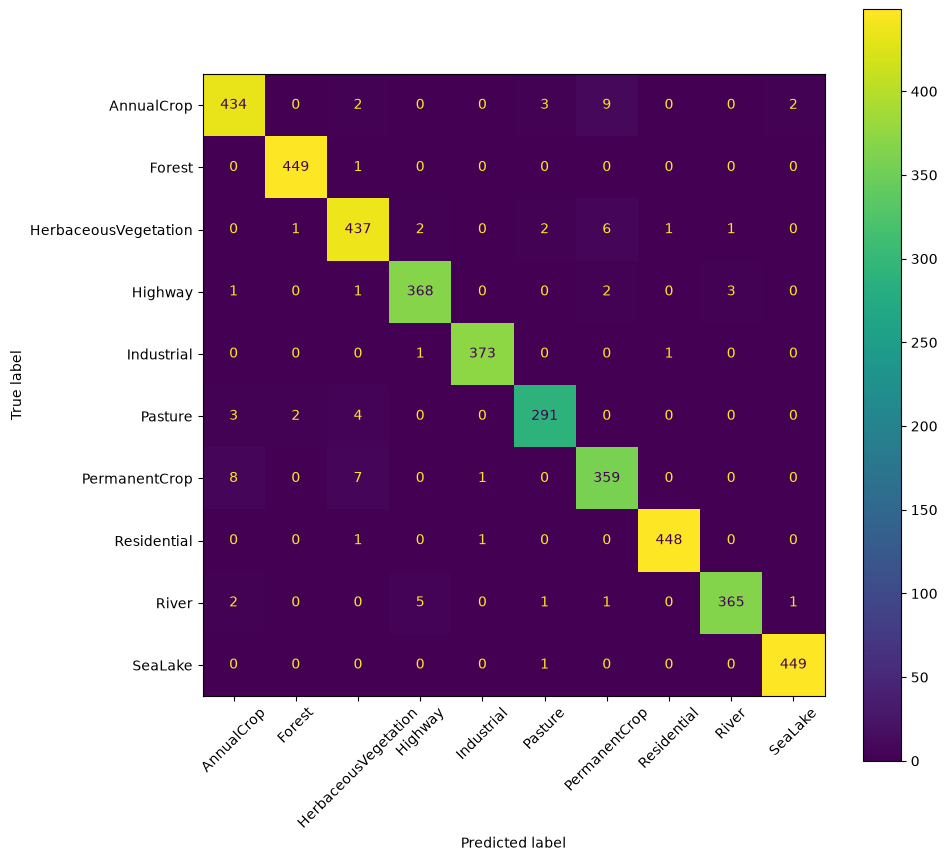

In [19]:
fig, ax = plt.subplots(figsize=(10, 9))
ConfusionMatrixDisplay.from_predictions(
    labels, preds, display_labels=class_names, xticks_rotation=45, ax=ax
)
plt.tight_layout()